In [2]:
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import random
from xgboost import XGBClassifier
import lime
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import shap
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from tqdm import tqdm
from sklearn.model_selection import train_test_split, GridSearchCV

Data Preprocessing

In [5]:
directory_buggy = "D:\\ICSE_Dataset\\CSVAllBuggy"

In [6]:
data_points = []

def convert_tensor_to_bool(tensor_str):
    if isinstance(tensor_str, str):
        return 'True' in tensor_str
    elif isinstance(tensor_str, bool):
        return tensor_str
    elif isinstance(tensor_str, int):
        return bool(tensor_str)
    return False

columns_to_delete = []

def process_directory(directory, label_filter):
    data_points = []
    for filename in os.listdir(directory):
        if filename.endswith('.csv') and any(label in filename for label in label_filter):
            label = next(label for label in label_filter if label in filename)
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path)
            if 'dying_relu' in df.columns:
                df['dying_relu'] = df['dying_relu'].apply(lambda x: convert_tensor_to_bool(x))
            df = df.drop(columns=columns_to_delete, errors='ignore')
            data_point = df.mean().to_frame().T
            data_point['label'] = label
            data_points.append(data_point)
    return data_points

label_filter = ['Activation', 'Hyperparameter', 'Loss', 'Layer']
data_points_correct = process_directory(directory_buggy, label_filter)
data_points_hyperparameter = process_directory(directory_buggy, ['Optimization'])

min_samples = min(len(data_points_correct), len(data_points_hyperparameter))
data_points_balanced = data_points_correct[:min_samples] + data_points_hyperparameter[:min_samples]
df_combined = pd.concat(data_points_balanced, ignore_index=True)
output_file = "D:\\ICSE_Dataset\\Optimization_correct_data.csv"
df_combined.to_csv(output_file, index=False)
print(f"Combined balanced data saved to {output_file}")

Combined balanced data saved to D:\ICSE_Dataset\Optimization_correct_data.csv


# Feature Processing

In [3]:
# read the data from the csv file
data = pd.read_csv("D:\\ICSE_Dataset\\Optimization_correct_data.csv")
df_combined = data.copy()
df_combined['label'] = df_combined['label'].apply(lambda x: 1 if x == 'Optimization' else 0)

In [4]:
X = df_combined.drop(columns=['label'])
y = df_combined['label']
X = X.apply(lambda x: x.fillna(x.mean()), axis=0)
X = X.replace([np.inf, -np.inf], np.nan).apply(lambda x: x.fillna(x.max()), axis=0)
for column in X.columns:
    if X[column].isna().sum() > 0 or np.isinf(X[column]).sum() > 0:
        X[column] = X[column].replace([np.inf, -np.inf], np.nan).fillna(X[column].mean())
    lower_quantile = X[column].quantile(0.01)
    upper_quantile = X[column].quantile(0.99)

    X[column] = X[column].clip(lower=lower_quantile, upper=upper_quantile)
X = X.apply(lambda x: x.fillna(x.mean()), axis=0)
X = X.replace([np.inf, -np.inf], np.nan).apply(lambda x: x.fillna(x.mean()), axis=0)
if X.isna().sum().sum() > 0 or np.isinf(X).sum().sum() > 0:
    print("There are still NaNs or infinite values in the DataFrame. Additional cleaning needed.")
else:
    print("Data cleaning completed successfully. No NaNs or infinite values remain.")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)


Data cleaning completed successfully. No NaNs or infinite values remain.
X_train shape:  (1984, 31)
X_test shape:  (496, 31)
y_train shape:  (1984, 2)
y_test shape:  (496, 2)


Feature importance 

In [5]:
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)

Feature ranking:
1. feature 29 (0.153831)
2. feature 30 (0.027016)
3. feature 7 (0.021573)
4. feature 23 (0.018548)
5. feature 28 (0.016331)
6. feature 8 (0.008468)
7. feature 9 (0.006653)
8. feature 2 (0.004435)
9. feature 4 (0.003427)
10. feature 6 (0.002823)
11. feature 14 (0.000000)
12. feature 1 (0.000000)
13. feature 3 (0.000000)
14. feature 11 (0.000000)
15. feature 12 (0.000000)
16. feature 13 (0.000000)
17. feature 15 (0.000000)
18. feature 16 (0.000000)
19. feature 17 (0.000000)
20. feature 18 (0.000000)
21. feature 19 (0.000000)
22. feature 20 (0.000000)
23. feature 25 (0.000000)
24. feature 26 (0.000000)
25. feature 0 (0.000000)
26. feature 24 (-0.000403)
27. feature 5 (-0.001613)
28. feature 27 (-0.001815)
29. feature 21 (-0.002218)
30. feature 22 (-0.002823)
31. feature 10 (-0.003427)


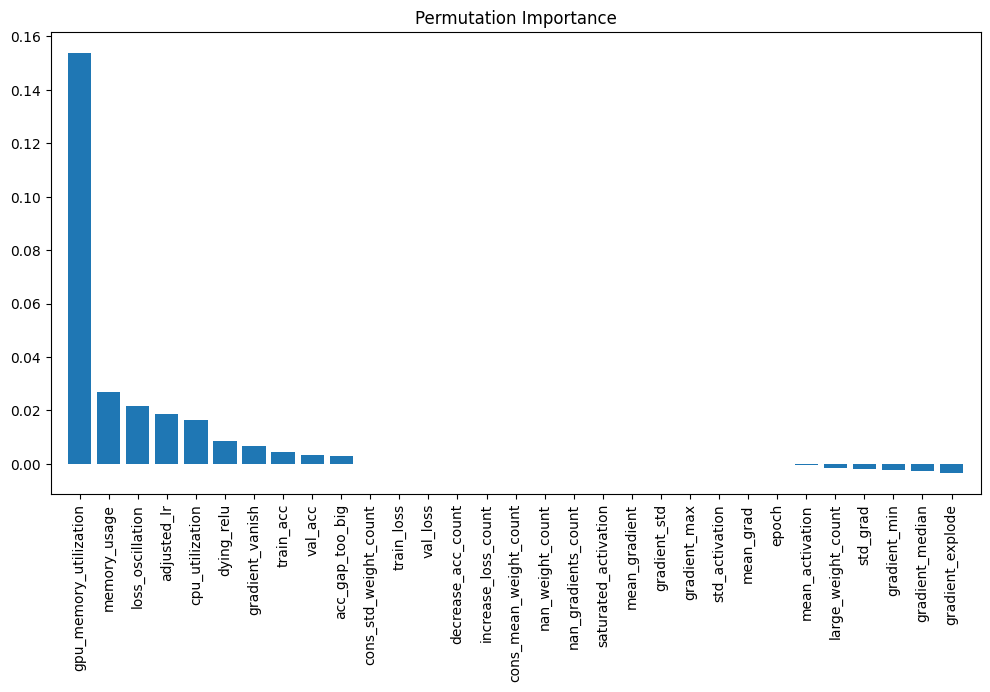

In [6]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
indices = result.importances_mean.argsort()[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], result.importances_mean[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Permutation Importance")
plt.bar(range(X_train.shape[1]), result.importances_mean[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


Feature ranking:
1. feature 24 (0.179576)
2. feature 10 (0.154252)
3. feature 8 (0.136663)
4. feature 27 (0.074127)
5. feature 7 (0.064907)
6. feature 23 (0.057199)
7. feature 29 (0.056187)
8. feature 4 (0.043496)
9. feature 19 (0.042651)
10. feature 2 (0.041578)
11. feature 30 (0.028614)
12. feature 5 (0.027597)
13. feature 9 (0.026183)
14. feature 28 (0.020257)
15. feature 21 (0.015028)
16. feature 26 (0.013941)
17. feature 6 (0.013524)
18. feature 22 (0.004219)
19. feature 3 (0.000000)
20. feature 1 (0.000000)


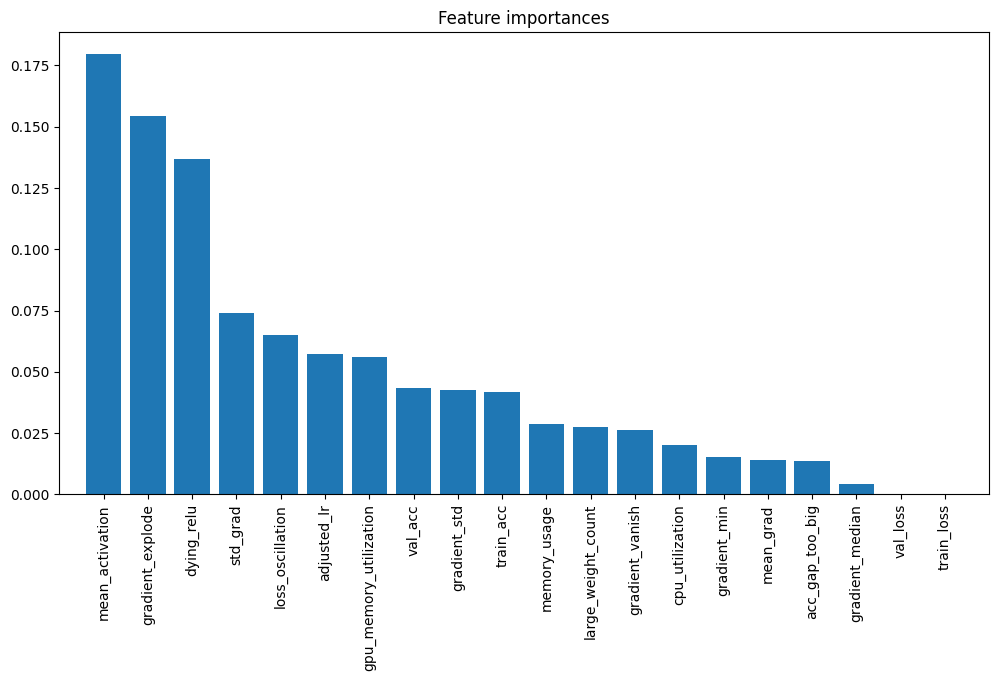

In [8]:
model = xgb.XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# print top 20 features with their name and index and score
feature_names = X.columns
feature_scores = model.feature_importances_
indices = np.argsort(feature_scores)[::-1]
print("Feature ranking:")
for f in range(20):
    print("%d. feature %d (%f)" % (f + 1, indices[f], feature_scores[indices[f]]))

# plot the top 20 features
feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature importances")
plt.bar(range(20), feature_scores[indices][:20], align="center")
plt.xticks(range(20), feature_names[:20], rotation=90)
plt.xlim([-1, 20])
plt.show()


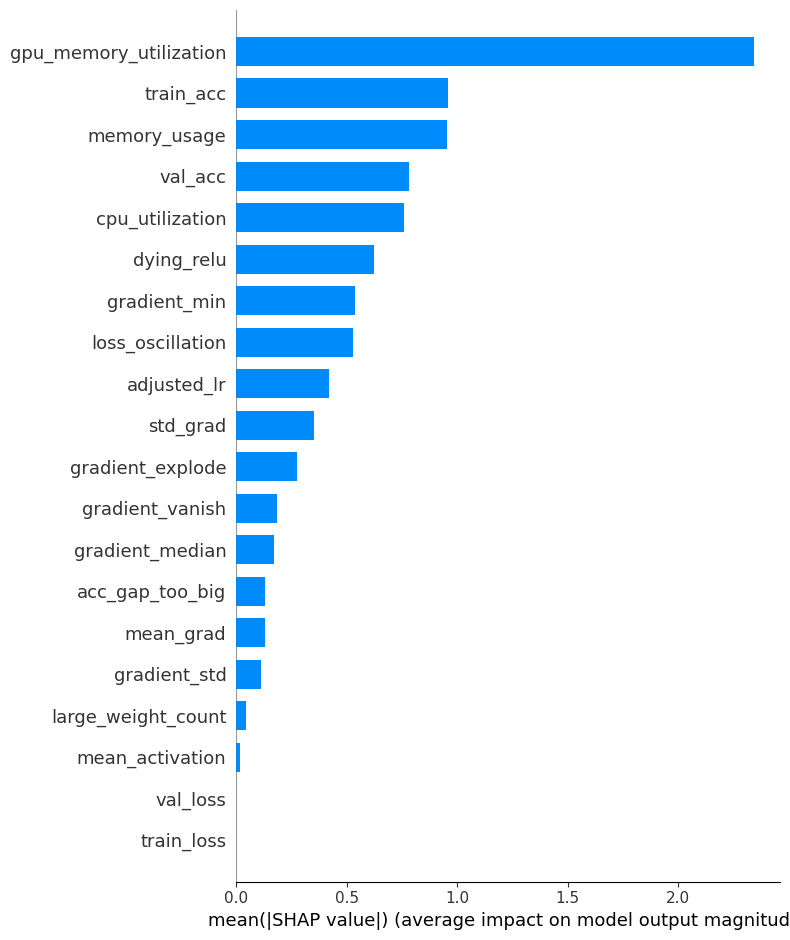

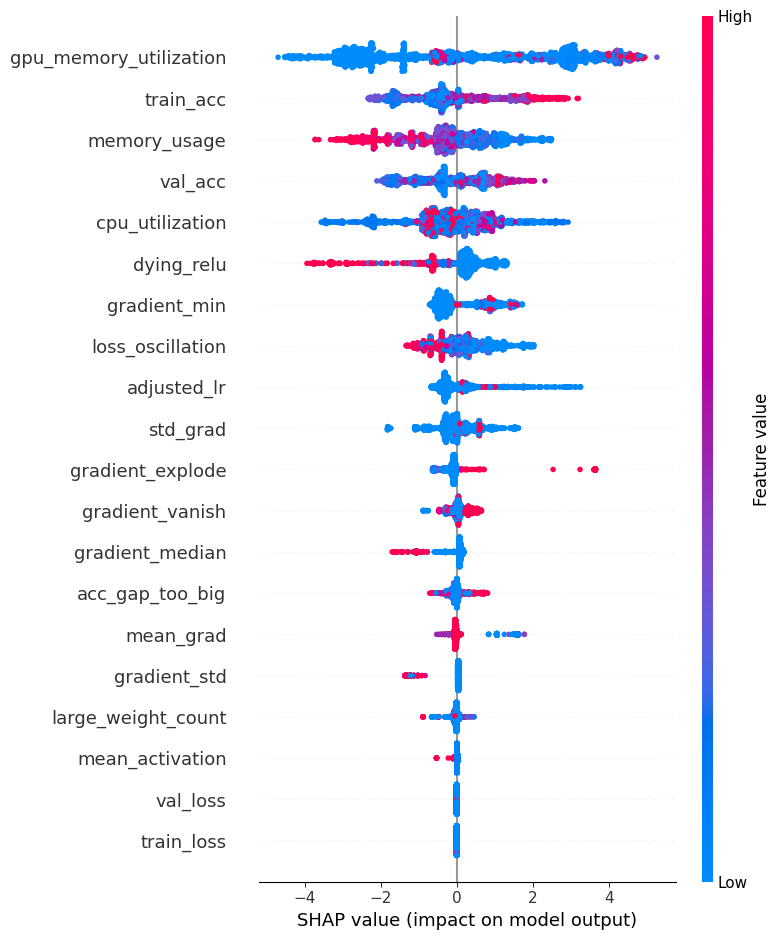

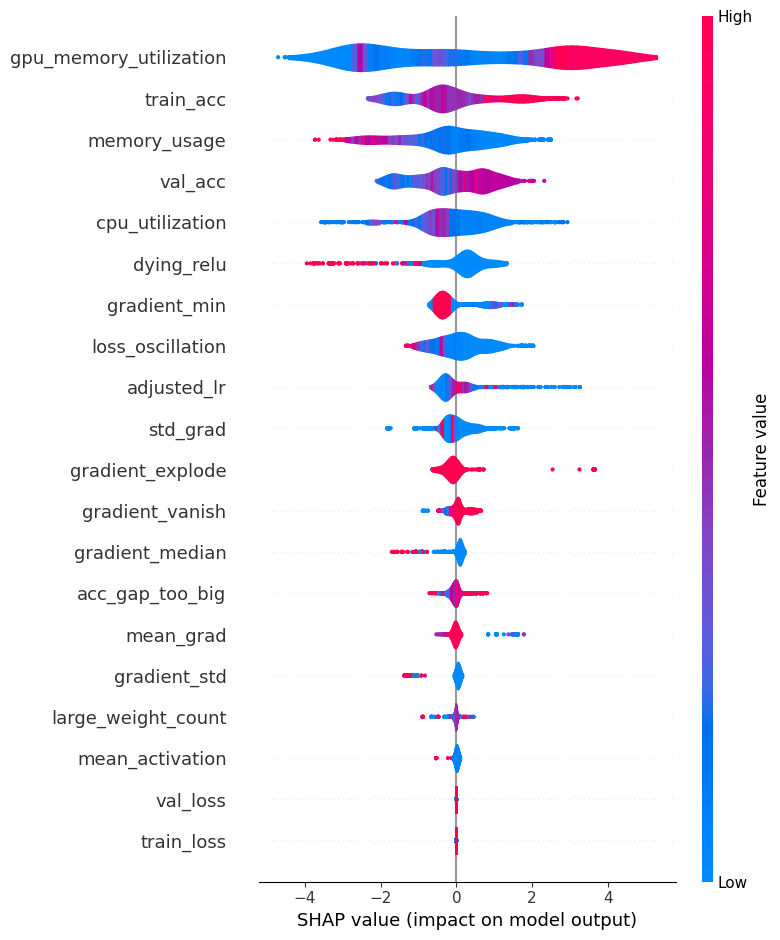

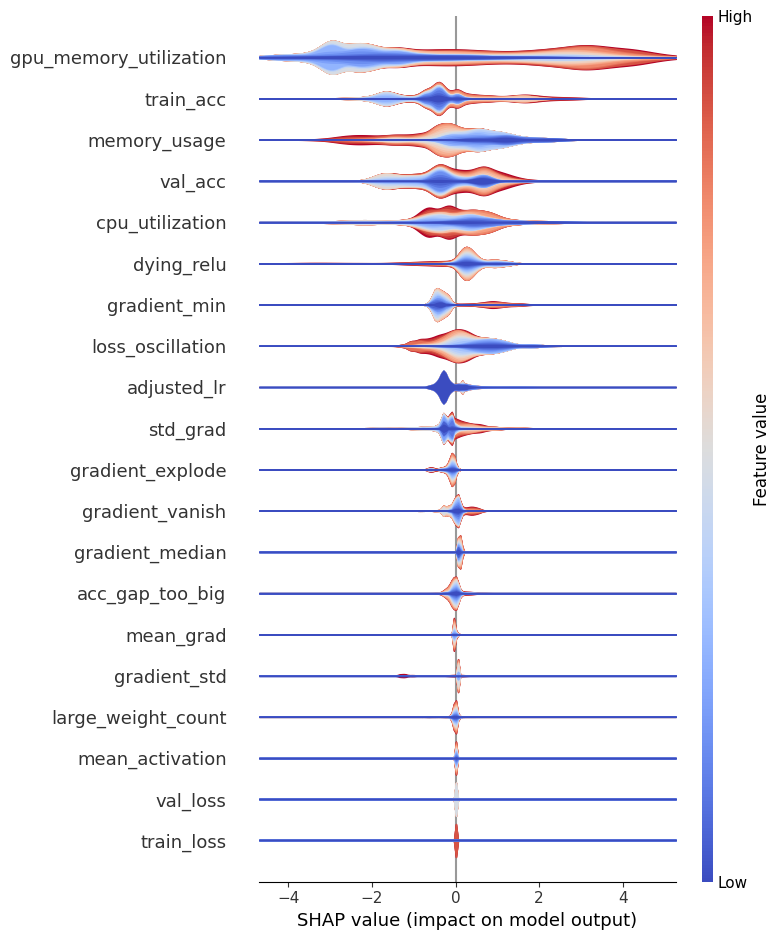

In [73]:
# Shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
feature_names = X.columns
shap.summary_plot(shap_values, X_train, feature_names=feature_names, plot_type='dot')
shap.summary_plot(shap_values, X_train, feature_names=feature_names, plot_type='violin')

Feature ranking:
1. feature 23 (-1.029013)
2. feature 2 (0.959788)
3. feature 10 (0.926945)
4. feature 7 (-0.890929)
5. feature 21 (-0.656820)
6. feature 4 (-0.634760)
7. feature 28 (0.512542)
8. feature 27 (-0.498434)
9. feature 8 (-0.443424)
10. feature 25 (-0.405403)
11. feature 30 (-0.354707)
12. feature 24 (-0.325616)
13. feature 6 (0.320482)
14. feature 1 (-0.281876)
15. feature 3 (-0.280070)
16. feature 9 (0.274641)
17. feature 22 (-0.157003)
18. feature 29 (0.147224)
19. feature 19 (-0.145352)
20. feature 18 (-0.126787)
21. feature 20 (-0.125856)
22. feature 26 (0.063790)
23. feature 5 (-0.062249)
24. feature 15 (0.000000)
25. feature 11 (0.000000)
26. feature 12 (0.000000)
27. feature 13 (0.000000)
28. feature 14 (0.000000)
29. feature 16 (0.000000)
30. feature 17 (0.000000)
31. feature 0 (0.000000)


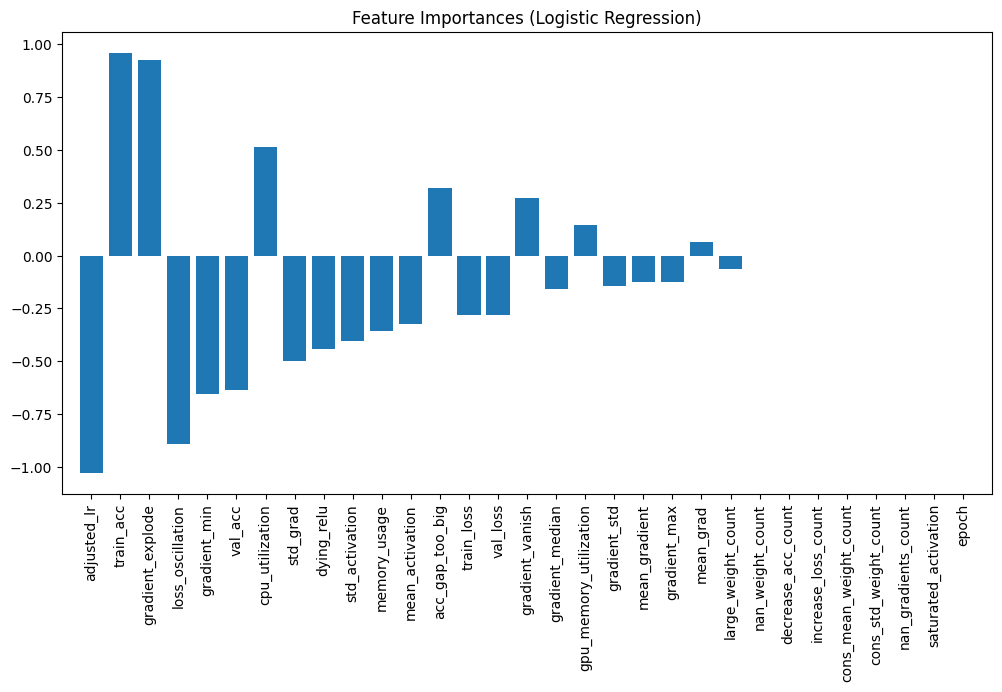

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
importance = model.coef_[0]
indices = np.argsort(np.abs(importance))[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importance[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Logistic Regression)")
plt.bar(range(X_train.shape[1]), importance[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


# Tree-based classifier

In [19]:
# def run_models_classification_report(X_train, X_test, y_train, y_test, verbose=True):
#     models = {
#         'LogisticRegression': LogisticRegression(max_iter=1000),
#         'DecisionTree': DecisionTreeClassifier(),
#         'RandomForest': RandomForestClassifier(),
#         'SVC': SVC(max_iter=1000),
#         'KNeighbors': KNeighborsClassifier(),
#         'MLP': MLPClassifier(max_iter=1000),
#         'GradientBoosting': GradientBoostingClassifier(),
#         'AdaBoost': AdaBoostClassifier(),
#         'Bagging': BaggingClassifier(),
#         'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
#     }
    
#     results = {}
#     cv_results = {}

#     for model_name, model in tqdm(models.items(), desc='Training Models', total=len(models)):
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)
#         results[model_name] = classification_report(y_test, y_pred, output_dict=True)
        
#         cv_scores = cross_val_score(model, X_train, y_train, cv=5)
#         cv_results[model_name] = cv_scores
        
#         if verbose:
#             print(model_name)
#             print("Classification Report:")
#             print(classification_report(y_test, y_pred))
#             print("Cross-Validation Scores:")
#             print(cv_scores)
#             print("Mean CV Score:", cv_scores.mean())
#             print("Standard Deviation of CV Scores:", cv_scores.std())
#             print()
            
#     return results, cv_results

# # Run the models
# results, cv_results = run_models_classification_report(X_train, X_test, y_train, y_test, verbose=False)

# for model_name in results.keys():
#     print(model_name)
#     print("Classification Report:")
#     print(results[model_name])
#     print("Cross-Validation Scores:")
#     print(cv_results[model_name])
#     print("Mean CV Score:", cv_results[model_name].mean())
#     print("Standard Deviation of CV Scores:", cv_results[model_name].std())
#     print()

Training Models:  70%|███████   | 7/10 [01:20<00:52, 17.43s/it]c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMM

LogisticRegression
Classification Report:
{'0': {'precision': 0.6612244897959184, 'recall': 0.6864406779661016, 'f1-score': 0.6735966735966736, 'support': 236.0}, '1': {'precision': 0.7051792828685259, 'recall': 0.6807692307692308, 'f1-score': 0.6927592954990215, 'support': 260.0}, 'accuracy': 0.6834677419354839, 'macro avg': {'precision': 0.6832018863322222, 'recall': 0.6836049543676662, 'f1-score': 0.6831779845478476, 'support': 496.0}, 'weighted avg': {'precision': 0.684265308745269, 'recall': 0.6834677419354839, 'f1-score': 0.6836415963680657, 'support': 496.0}}
Cross-Validation Scores:
[0.69269521 0.68261965 0.69521411 0.68513854 0.69191919]
Mean CV Score: 0.6895173396432843
Standard Deviation of CV Scores: 0.004797352991487034

DecisionTree
Classification Report:
{'0': {'precision': 0.9314516129032258, 'recall': 0.9788135593220338, 'f1-score': 0.9545454545454546, 'support': 236.0}, '1': {'precision': 0.9798387096774194, 'recall': 0.9346153846153846, 'f1-score': 0.9566929133858267

In [13]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
clf.fit(X_train, y_train)
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
k = 20
X_train_selected = X_train[:, indices[:k]]
X_test_selected = X_test[:, indices[:k]]
print("Feature ranking:")
for f in range(X_train_selected.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],  
    'max_features': ['sqrt', 'log2'] 
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True),
    param_grid=param_grid,
    cv=5, 
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train_selected, y_train)
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test_selected)
target_names = [str(cat) for cat in encoder.categories_[0]]

print(classification_report(y_test, y_pred, target_names=target_names))
print("OOB Score of Best Model: ", best_clf.oob_score_)
print("Best Parameters: ", grid_search.best_params_) 

Feature ranking:
1. feature 29 (0.215024)
2. feature 28 (0.120172)
3. feature 2 (0.110549)
4. feature 4 (0.097354)
5. feature 30 (0.094764)
6. feature 7 (0.085671)
7. feature 6 (0.053123)
8. feature 23 (0.044108)
9. feature 8 (0.042169)
10. feature 9 (0.036229)
11. feature 10 (0.024041)
12. feature 22 (0.015944)
13. feature 27 (0.014661)
14. feature 21 (0.009420)
15. feature 26 (0.009387)
16. feature 5 (0.007067)
17. feature 24 (0.006322)
18. feature 25 (0.004459)
19. feature 19 (0.004044)
20. feature 20 (0.002762)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       236
           1       0.98      0.98      0.98       260

    accuracy                           0.98       496
   macro avg       0.98      0.98      0.98       496
weighted avg       0.98      0.98      0.98       496

OOB Score of Best Model:  0.9717741935483871
Best Parameters:  {'max_depth': 20, 'max_fe

In [14]:
# print the name of the feature and the importance of the feature
for i in range(len(indices)):
    print(f"{X.columns[indices[i]]}: {importances[indices[i]]}")

gpu_memory_utilization: 0.2150239696308701
cpu_utilization: 0.12017180596455602
train_acc: 0.11054865562445972
val_acc: 0.09735385863568721
memory_usage: 0.09476408306750861
loss_oscillation: 0.08567122865117315
acc_gap_too_big: 0.05312257314393362
adjusted_lr: 0.04410754433407736
dying_relu: 0.042169419851624215
gradient_vanish: 0.03622930948257962
gradient_explode: 0.024040687306158336
gradient_median: 0.01594376522925717
std_grad: 0.014661485560246918
gradient_min: 0.009420003764910274
mean_grad: 0.009386777883780246
large_weight_count: 0.007066691636617266
mean_activation: 0.006321756756698756
std_activation: 0.004459136063107359
gradient_std: 0.0040441868567964705
gradient_max: 0.0027619263617678323
mean_gradient: 0.0014290363360674996
train_loss: 0.0010815998322991328
val_loss: 0.00022049802582322321
nan_weight_count: 0.0
decrease_acc_count: 0.0
increase_loss_count: 0.0
cons_mean_weight_count: 0.0
cons_std_weight_count: 0.0
nan_gradients_count: 0.0
saturated_activation: 0.0
epoch

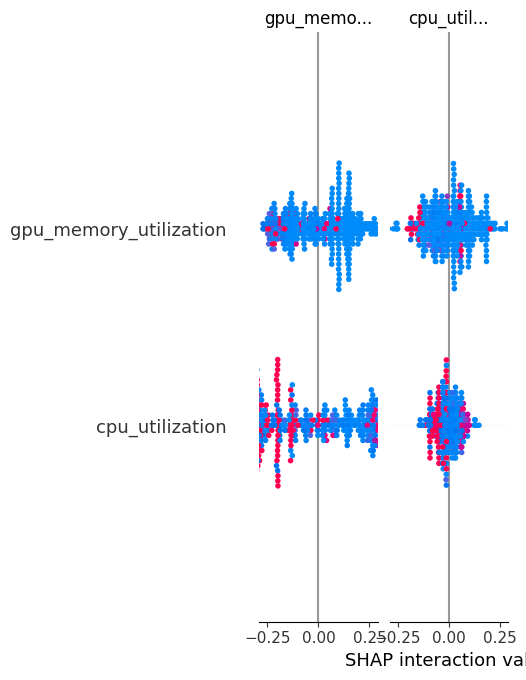

<Figure size 640x480 with 0 Axes>

In [16]:
target_names = ['Not Optimization', 'Optimization'] 

explainer = LimeTabularExplainer(
    training_data=X_train_selected,  
    feature_names=[f'feature_{i}' for i in range(X_train_selected.shape[1])],  
    class_names=target_names,  
    mode='classification'
)

i = 2
exp = explainer.explain_instance(X_test_selected[i], best_clf.predict_proba, num_features=10)
exp.show_in_notebook(show_table=True, show_all=False)
plt.savefig('lime_explanation.png')